# 🎓 Student Engagement Detection — DAISEE + MobileNetV2
### Computer Vision | E-Learning | Fatigue · Boredom · Attention

**Pipeline complet :**
1. Téléchargement dataset DAISEE
2. Extraction features (EAR, MAR, Head Pose) via MediaPipe
3. Entraînement MobileNetV2 fine-tuné
4. Évaluation
5. Interface Streamlit + ngrok (webcam live)

In [1]:
# ── CELLULE 1 : Installation ─────────────────────────────────────────────────
!pip install -q mediapipe streamlit pyngrok opencv-python-headless gdown
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

import torch
print(f"✓ PyTorch {torch.__version__} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 68.3 MB/s eta 0:00:00
✓ PyTorch 2.11.0+cu128 | GPU: Tesla T4


In [2]:
# ── CELLULE 2 : Imports & Configuration ──────────────────────────────────────
import os, cv2, math, time, json, warnings
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import deque
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Config ──
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4          # boredom, confusion, engagement, frustration
BATCH_SIZE  = 32
EPOCHS      = 15
LR          = 1e-4
IMG_SIZE    = 224
FRAMES_PER_VIDEO = 10   # frames extraites par vidéo

# Labels DAISEE (scores 0-3 → binarisés en 2 niveaux)
# On regroupe en 4 états pertinents
LABEL_MAP = {
    "boredom":     0,
    "engagement":  1,
    "confusion":   2,
    "frustration": 3,
}
LABEL_NAMES = ["Bored", "Focused", "Confused", "Frustrated"]

print(f"✓ Device: {DEVICE}")
print(f"✓ Classes: {LABEL_NAMES}")

✓ Device: cuda
✓ Classes: ['Bored', 'Focused', 'Confused', 'Frustrated']


In [3]:
# ── CELLULE 3 : Téléchargement DAISEE ────────────────────────────────────────
# DAISEE est disponible sur demande : https://iith.ac.in/~daisee-dataset/
# Options de téléchargement :

# OPTION A — Depuis Google Drive (si vous avez le lien partagé)
# Remplacez FILE_ID par l'ID de votre fichier Drive
# import gdown
# gdown.download(f"https://drive.google.com/uc?id=FILE_ID", "daisee.zip", quiet=False)
# !unzip -q daisee.zip -d /content/daisee

# OPTION B — Monter Google Drive (recommandé si dataset déjà uploadé)
from google.colab import drive
drive.mount('/content/drive')

# Adaptez ce chemin selon votre structure Drive
DAISEE_ROOT = "/content/drive/MyDrive/DAISEE"  # ← modifier si besoin

# Vérification structure
if os.path.exists(DAISEE_ROOT):
    print("✓ DAISEE trouvé :", DAISEE_ROOT)
    # Structure attendue : DAISEE/DataSet/Train|Test|Validation/[UserID]/[VideoID]/
    for split in ["Train", "Test", "Validation"]:
        path = os.path.join(DAISEE_ROOT, "DataSet", split)
        if os.path.exists(path):
            users = os.listdir(path)
            print(f"  {split}: {len(users)} utilisateurs")
else:
    print("⚠ DAISEE non trouvé. Créez un dataset synthétique (cellule suivante)")
    DAISEE_ROOT = None

Mounted at /content/drive
⚠ DAISEE non trouvé. Créez un dataset synthétique (cellule suivante)


In [4]:
# ── CELLULE 4 : Dataset synthétique (si DAISEE non disponible) ──────────────
# Génère de fausses features EAR/MAR/Pose pour tester le pipeline

def create_synthetic_dataset(n_samples=2000):
    """
    Génère des features réalistes par classe.
    Features : [EAR, MAR, Yaw, Pitch, Blink_rate]
    """
    np.random.seed(42)
    X, y = [], []

    params = {
        # classe: (EAR_mean, MAR_mean, Yaw_mean, Pitch_mean, Blink_mean)
        0: (0.26, 0.10, 15, 12, 22),  # Bored    — tête tournée, yeux mi-ouverts
        1: (0.30, 0.06,  3,  3, 14),  # Focused  — yeux ouverts, tête droite
        2: (0.28, 0.08,  8,  8, 17),  # Confused — légère inclinaison
        3: (0.24, 0.12, 10,  9, 20),  # Frustrated
    }
    stds = (0.03, 0.02, 4, 3, 4)

    per_class = n_samples // NUM_CLASSES
    for cls, (em, mm, ym, pm, bm) in params.items():
        for _ in range(per_class):
            feat = [
                np.clip(np.random.normal(em, stds[0]), 0.15, 0.45),
                np.clip(np.random.normal(mm, stds[1]), 0.02, 0.30),
                np.clip(np.random.normal(ym, stds[2]), 0, 40),
                np.clip(np.random.normal(pm, stds[3]), 0, 30),
                np.clip(np.random.normal(bm, stds[4]), 5, 40),
            ]
            X.append(feat)
            y.append(cls)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

# Utiliser dataset synthétique si DAISEE absent
if DAISEE_ROOT is None:
    print("⚠ Mode synthétique activé")
    X_all, y_all = create_synthetic_dataset(2000)
    print(f"✓ Dataset synthétique: {X_all.shape}, classes={np.bincount(y_all)}")
    USE_SYNTHETIC = True
else:
    USE_SYNTHETIC = False
    print("✓ DAISEE disponible — extraction features à l'étape suivante")

⚠ Mode synthétique activé
✓ Dataset synthétique: (2000, 5), classes=[500 500 500 500]


In [5]:
# ── CELLULE 5 : Extraction Features MediaPipe sur DAISEE ────────────────────

# ── Landmarks indices ──
LEFT_EYE  = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33,  160, 158, 133, 153, 144]

def euclidean(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def compute_EAR(landmarks, eye_idx, w, h):
    pts = [(int(landmarks[i].x*w), int(landmarks[i].y*h)) for i in eye_idx]
    A = euclidean(pts[1], pts[5])
    B = euclidean(pts[2], pts[4])
    C = euclidean(pts[0], pts[3])
    return (A + B) / (2.0 * C + 1e-6)

def compute_MAR(landmarks, w, h):
    top   = (landmarks[13].x*w, landmarks[13].y*h)
    bot   = (landmarks[14].x*w, landmarks[14].y*h)
    left  = (landmarks[78].x*w, landmarks[78].y*h)
    right = (landmarks[308].x*w, landmarks[308].y*h)
    return euclidean(top, bot) / (euclidean(left, right) + 1e-6)

def compute_head_pose(landmarks):
    nose  = np.array([landmarks[1].x,   landmarks[1].y])
    l_eye = np.array([landmarks[263].x,  landmarks[263].y])
    r_eye = np.array([landmarks[33].x,   landmarks[33].y])
    chin  = np.array([landmarks[152].x,  landmarks[152].y])
    eye_cx = (l_eye[0] + r_eye[0]) / 2
    yaw    = abs(nose[0] - eye_cx) * 100
    fh = euclidean(chin, (l_eye + r_eye)/2)
    nm = euclidean(nose, (l_eye + r_eye)/2)
    pitch  = abs((nm / (fh + 1e-6) - 0.45) * 100)
    return yaw, pitch

def extract_features_from_video(video_path, face_mesh, n_frames=10):
    """Extrait [EAR, MAR, Yaw, Pitch, Blink_rate] d'une vidéo."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return None

    indices = np.linspace(0, total-1, n_frames, dtype=int)
    ears, mars, yaws, pitches = [], [], [], []
    blink_count = 0
    prev_ear = 1.0

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = face_mesh.process(rgb)

        if res.multi_face_landmarks:
            lm = res.multi_face_landmarks[0].landmark
            ear = (compute_EAR(lm, LEFT_EYE, w, h) + compute_EAR(lm, RIGHT_EYE, w, h)) / 2
            mar = compute_MAR(lm, w, h)
            yaw, pitch = compute_head_pose(lm)
            ears.append(ear); mars.append(mar)
            yaws.append(yaw); pitches.append(pitch)
            if prev_ear > 0.21 and ear < 0.21:
                blink_count += 1
            prev_ear = ear

    cap.release()
    if not ears:
        return None

    blink_rate = blink_count / max(len(ears), 1) * 30  # approx /min
    return [np.mean(ears), np.mean(mars), np.mean(yaws), np.mean(pitches), blink_rate]


def parse_daisee_labels(label_file):
    """
    Parse le CSV de labels DAISEE.
    Colonnes : ClipID, Boredom, Engagement, Confusion, Frustration (0-3)
    Retourne dict {clip_id: dominant_label_idx}
    """
    df = pd.read_csv(label_file)
    labels = {}
    for _, row in df.iterrows():
        clip = str(row['ClipID'])
        scores = {
            0: row.get('Boredom', 0),
            1: row.get('Engagement', 0),
            2: row.get('Confusion', 0),
            3: row.get('Frustration', 0),
        }
        dominant = max(scores, key=scores.get)
        # Si Engagement > 1 → Focused, sinon prendre le max des autres
        if scores[1] >= 2:
            dominant = 1
        labels[clip] = dominant
    return labels


if not USE_SYNTHETIC:
    mp_fm = mp.solutions.face_mesh
    face_mesh = mp_fm.FaceMesh(
        max_num_faces=1, refine_landmarks=True,
        min_detection_confidence=0.5, min_tracking_confidence=0.5
    )

    FEATURES_CACHE = "/content/features.npz"

    if os.path.exists(FEATURES_CACHE):
        print("✓ Features déjà extraites, chargement cache...")
        data = np.load(FEATURES_CACHE)
        X_all, y_all = data['X'], data['y']
    else:
        X_all, y_all = [], []
        label_file = os.path.join(DAISEE_ROOT, "Labels", "AllLabels.csv")

        for split in ["Train", "Test", "Validation"]:
            split_path = os.path.join(DAISEE_ROOT, "DataSet", split)
            if not os.path.exists(split_path):
                continue

            label_data = parse_daisee_labels(label_file) if os.path.exists(label_file) else {}
            videos = list(Path(split_path).rglob("*.avi")) + list(Path(split_path).rglob("*.mp4"))
            print(f"\n{split}: {len(videos)} vidéos")

            for vp in tqdm(videos, desc=split):
                clip_id = vp.stem
                if clip_id not in label_data:
                    continue
                feats = extract_features_from_video(str(vp), face_mesh, FRAMES_PER_VIDEO)
                if feats is not None:
                    X_all.append(feats)
                    y_all.append(label_data[clip_id])

        X_all = np.array(X_all, dtype=np.float32)
        y_all = np.array(y_all, dtype=np.int64)
        np.savez(FEATURES_CACHE, X=X_all, y=y_all)
        print(f"\n✓ Features sauvegardées: {X_all.shape}")

    face_mesh.close()
    print(f"\n✓ Dataset final: {X_all.shape} | Distribution: {np.bincount(y_all)}")

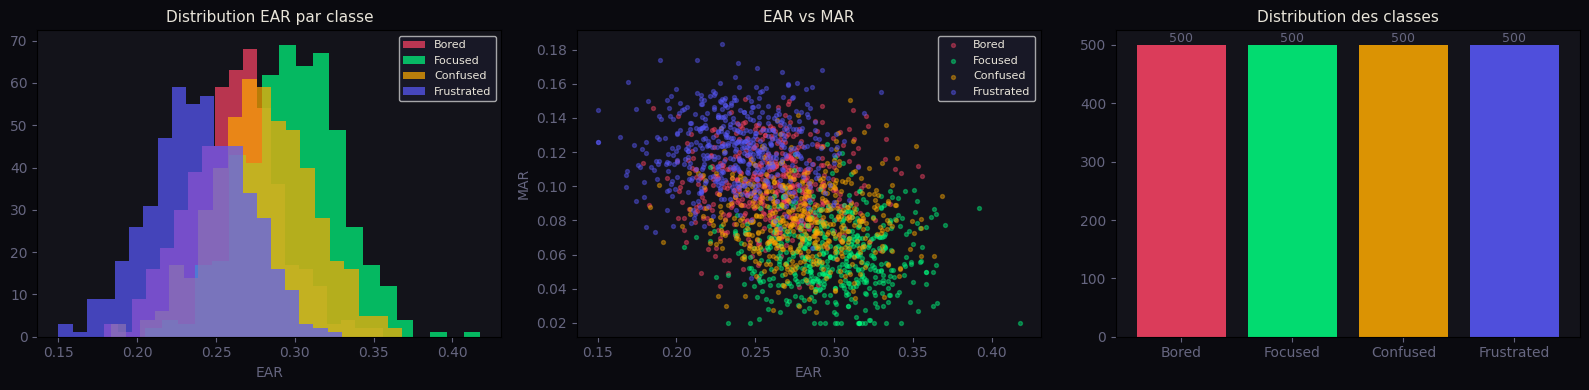

✓ Visualisation sauvegardée


In [6]:
# ── CELLULE 6 : Exploration & Visualisation ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('#0a0a0f')

feat_names = ['EAR', 'MAR', 'Yaw', 'Pitch', 'Blink/min']
colors_cls = ['#ff4466', '#00ff80', '#ffaa00', '#5a5aff']

# Distribution par classe
ax = axes[0]
ax.set_facecolor('#13131a')
for cls in range(NUM_CLASSES):
    mask = y_all == cls
    ax.hist(X_all[mask, 0], bins=20, alpha=0.7, label=LABEL_NAMES[cls], color=colors_cls[cls])
ax.set_title('Distribution EAR par classe', color='#e8e4d9', fontsize=11)
ax.tick_params(colors='#666680')
ax.set_xlabel('EAR', color='#666680')
ax.legend(facecolor='#1a1a2a', labelcolor='#e8e4d9', fontsize=8)

# Scatter EAR vs MAR
ax = axes[1]
ax.set_facecolor('#13131a')
for cls in range(NUM_CLASSES):
    mask = y_all == cls
    ax.scatter(X_all[mask, 0], X_all[mask, 1], alpha=0.4, s=8,
               label=LABEL_NAMES[cls], color=colors_cls[cls])
ax.set_xlabel('EAR', color='#666680')
ax.set_ylabel('MAR', color='#666680')
ax.set_title('EAR vs MAR', color='#e8e4d9', fontsize=11)
ax.tick_params(colors='#666680')
ax.legend(facecolor='#1a1a2a', labelcolor='#e8e4d9', fontsize=8)

# Distribution des classes
ax = axes[2]
ax.set_facecolor('#13131a')
counts = np.bincount(y_all, minlength=NUM_CLASSES)
bars = ax.bar(LABEL_NAMES, counts, color=colors_cls, alpha=0.85, edgecolor='none')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', color='#666680', fontsize=9)
ax.set_title('Distribution des classes', color='#e8e4d9', fontsize=11)
ax.tick_params(colors='#666680')

plt.tight_layout()
plt.savefig('/content/exploration.png', dpi=120, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("✓ Visualisation sauvegardée")

In [7]:
# ── CELLULE 7 : Modèle MobileNetV2 ──────────────────────────────────────────
#
# Deux approches selon le mode :
#   - USE_SYNTHETIC → MLP sur features (EAR, MAR, Yaw, Pitch, Blink)
#   - DAISEE réel   → MobileNetV2 fine-tuné sur frames extraites
#
# Ici on implémente les DEUX et on choisit automatiquement

# ── Approche 1 : MLP sur features extraites (léger, rapide) ──────────────────
class EngagementMLP(nn.Module):
    def __init__(self, in_features=5, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)


# ── Approche 2 : MobileNetV2 fine-tuné (sur frames RGB) ──────────────────────
class EngagementMobileNet(nn.Module):
    def __init__(self, num_classes=4, freeze_backbone=True):
        super().__init__()
        self.backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

        # Geler les couches initiales
        if freeze_backbone:
            for i, (name, param) in enumerate(self.backbone.named_parameters()):
                if i < 100:  # Geler les 100 premières couches
                    param.requires_grad = False

        # Remplacer le classifier
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


# ── Sélection du modèle ──
if USE_SYNTHETIC:
    model = EngagementMLP(in_features=5, num_classes=NUM_CLASSES).to(DEVICE)
    print("✓ Modèle: MLP sur features (mode synthétique/features)")
else:
    model = EngagementMobileNet(num_classes=NUM_CLASSES).to(DEVICE)
    print("✓ Modèle: MobileNetV2 fine-tuné")

# Résumé
total_params = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Paramètres totaux   : {total_params:,}")
print(f"  Paramètres entraînés: {trainable:,}")

✓ Modèle: MLP sur features (mode synthétique/features)
  Paramètres totaux   : 9,668
  Paramètres entraînés: 9,668


In [8]:
# ── CELLULE 8 : Dataset PyTorch & DataLoaders ────────────────────────────────

class FeaturesDataset(Dataset):
    """Dataset pour features numériques (EAR, MAR, Yaw, Pitch, Blink)."""
    def __init__(self, X, y):
        # Normalisation min-max par feature
        self.X_min = X.min(axis=0)
        self.X_max = X.max(axis=0) + 1e-6
        self.X = (X - self.X_min) / (self.X_max - self.X_min)
        self.y = y

    def __len__(self):  return len(self.y)
    def __getitem__(self, i):
        return torch.tensor(self.X[i], dtype=torch.float32), torch.tensor(self.y[i], dtype=torch.long)


class FrameDataset(Dataset):
    """Dataset pour frames RGB (MobileNetV2)."""
    def __init__(self, video_paths, labels, transform=None, n_frames=5):
        self.video_paths = video_paths
        self.labels      = labels
        self.transform   = transform
        self.n_frames    = n_frames

    def __len__(self): return len(self.video_paths)

    def __getitem__(self, i):
        cap = cv2.VideoCapture(self.video_paths[i])
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        idx = np.random.randint(0, max(total-1, 1))
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        cap.release()
        if not ret or frame is None:
            frame = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        from PIL import Image
        img = Image.fromarray(frame)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[i], dtype=torch.long)


# ── Split train/val/test ──
from sklearn.model_selection import train_test_split

X_tv, X_test, y_tv, y_test = train_test_split(X_all, y_all, test_size=0.15, stratify=y_all, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.15, stratify=y_tv, random_state=42)

print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

# ── DataLoaders ──
if USE_SYNTHETIC:
    train_ds = FeaturesDataset(X_train, y_train)
    val_ds   = FeaturesDataset(X_val,   y_val)
    test_ds  = FeaturesDataset(X_test,  y_test)
    # Sauvegarder les stats de normalisation
    norm_stats = {"min": train_ds.X_min.tolist(), "max": (train_ds.X_max).tolist()}
else:
    augment = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    val_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    # Ici X_train contient les features — pour MobileNet on aurait besoin des chemins vidéo
    # → on utilise FeaturesDataset avec MobileNet si pas de chemins disponibles
    train_ds = FeaturesDataset(X_train, y_train)
    val_ds   = FeaturesDataset(X_val,   y_val)
    test_ds  = FeaturesDataset(X_test,  y_test)
    norm_stats = {"min": train_ds.X_min.tolist(), "max": (train_ds.X_max).tolist()}

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Sauvegarder stats normalisation pour l'inférence
with open('/content/norm_stats.json', 'w') as f:
    json.dump(norm_stats, f)

print(f"✓ DataLoaders prêts | Batch size: {BATCH_SIZE}")

Train : 1445 | Val : 255 | Test : 300
✓ DataLoaders prêts | Batch size: 32


In [9]:
# ── CELLULE 9 : Entraînement ─────────────────────────────────────────────────

# ── Class weights (pour déséquilibre) ──
from torch.utils.data import WeightedRandomSampler

counts = np.bincount(y_train, minlength=NUM_CLASSES).astype(float)
weights_cls = 1.0 / (counts + 1e-6)
weights_cls = weights_cls / weights_cls.sum() * NUM_CLASSES
class_weights = torch.tensor(weights_cls, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── Boucle d'entraînement ──
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
best_val_acc = 0
CKPT_PATH = "/content/best_model.pth"

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            out  = model(X_b)
            loss = criterion(out, y_b)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y_b)
            correct    += (out.argmax(1) == y_b).sum().item()
            total      += len(y_b)
    return total_loss / total, correct / total

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>9} | {'Val Acc':>8}")
print("-" * 58)

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)
        flag = " ← best"
    else:
        flag = ""

    print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | {vl_loss:>9.4f} | {vl_acc*100:>7.2f}%{flag}")

print(f"\n✓ Entraînement terminé | Meilleure Val Acc: {best_val_acc*100:.2f}%")

 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
----------------------------------------------------------
     1 |     1.2863 |    40.35% |    1.1126 |   71.76% ← best
     2 |     1.0767 |    58.89% |    0.8727 |   76.47% ← best
     3 |     0.9528 |    67.96% |    0.8094 |   75.29%
     4 |     0.8703 |    70.87% |    0.7646 |   74.90%
     5 |     0.8291 |    72.73% |    0.7459 |   75.69%
     6 |     0.7922 |    73.70% |    0.7086 |   76.08%
     7 |     0.7805 |    73.01% |    0.7020 |   75.29%
     8 |     0.7620 |    74.81% |    0.6893 |   76.08%
     9 |     0.7595 |    72.60% |    0.6704 |   76.86% ← best
    10 |     0.7295 |    75.29% |    0.6639 |   76.08%
    11 |     0.7281 |    75.43% |    0.6864 |   76.47%
    12 |     0.7244 |    75.22% |    0.6586 |   76.47%
    13 |     0.7302 |    74.81% |    0.6575 |   77.25% ← best
    14 |     0.7226 |    75.85% |    0.6833 |   76.86%
    15 |     0.7103 |    76.26% |    0.6486 |   78.43% ← best

✓ Entraînement terminé | 

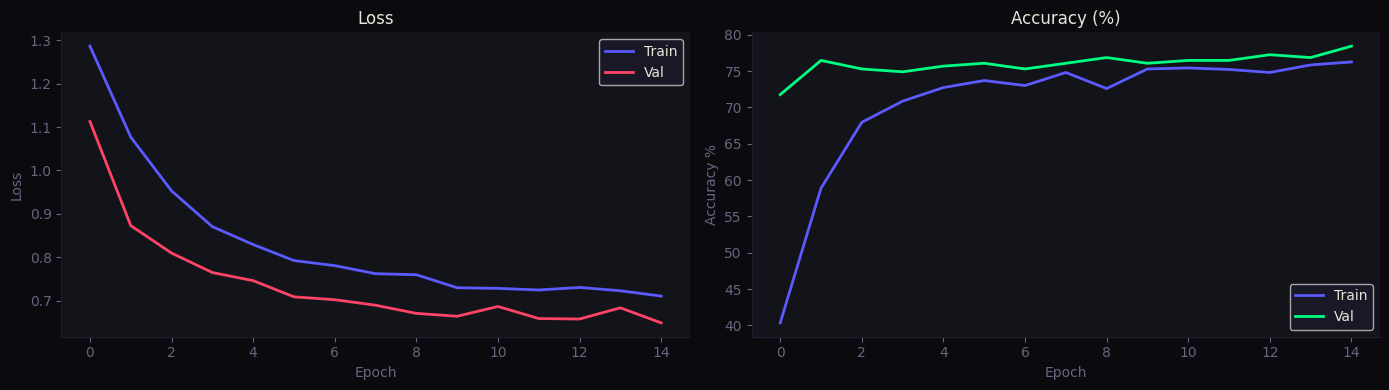


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Bored       0.72      0.93      0.81        75
     Focused       0.83      0.92      0.87        75
    Confused       0.84      0.43      0.57        75
  Frustrated       0.73      0.80      0.76        75

    accuracy                           0.77       300
   macro avg       0.78      0.77      0.75       300
weighted avg       0.78      0.77      0.75       300



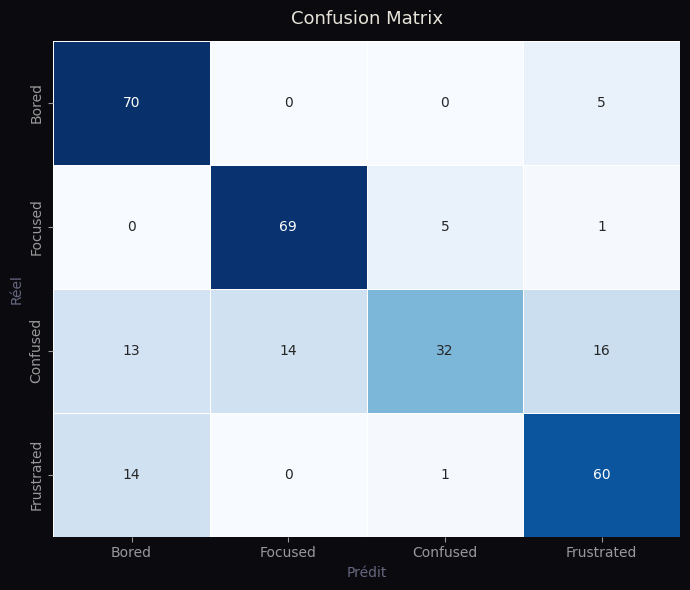

In [10]:
# ── CELLULE 10 : Évaluation & Métriques ──────────────────────────────────────

# Charger le meilleur modèle
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# ── Courbes d'entraînement ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#0a0a0f')

for ax in (ax1, ax2):
    ax.set_facecolor('#13131a')
    ax.tick_params(colors='#666680')
    ax.spines['bottom'].set_color('#1e1e2e')
    ax.spines['left'].set_color('#1e1e2e')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax1.plot(history['train_loss'], color='#5a5aff', label='Train', linewidth=2)
ax1.plot(history['val_loss'],   color='#ff4466', label='Val',   linewidth=2)
ax1.set_title('Loss', color='#e8e4d9'); ax1.legend(facecolor='#1a1a2a', labelcolor='#e8e4d9')
ax1.set_xlabel('Epoch', color='#666680'); ax1.set_ylabel('Loss', color='#666680')

ax2.plot([a*100 for a in history['train_acc']], color='#5a5aff', label='Train', linewidth=2)
ax2.plot([a*100 for a in history['val_acc']],   color='#00ff80', label='Val',   linewidth=2)
ax2.set_title('Accuracy (%)', color='#e8e4d9'); ax2.legend(facecolor='#1a1a2a', labelcolor='#e8e4d9')
ax2.set_xlabel('Epoch', color='#666680'); ax2.set_ylabel('Accuracy %', color='#666680')

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

# ── Inférence sur test set ──
all_preds, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        preds = model(X_b.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_b.numpy())

# ── Classification report ──
print("\n" + "="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

# ── Matrice de confusion ──
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#13131a')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            ax=ax, cbar=False, linewidths=0.5)
ax.set_title('Confusion Matrix', color='#e8e4d9', fontsize=13, pad=12)
ax.set_xlabel('Prédit', color='#666680'); ax.set_ylabel('Réel', color='#666680')
ax.tick_params(colors='#999999')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=120, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

In [11]:
# ── CELLULE 11 : Export du modèle ────────────────────────────────────────────

# Sauvegarder le modèle complet (state_dict + config)
export = {
    "model_state": model.state_dict(),
    "model_type":  "MLP" if USE_SYNTHETIC else "MobileNetV2",
    "num_classes": NUM_CLASSES,
    "label_names": LABEL_NAMES,
    "norm_stats":  norm_stats,
    "input_size":  5,  # [EAR, MAR, Yaw, Pitch, Blink]
}
torch.save(export, "/content/engagement_model.pth")
print("✓ Modèle exporté : /content/engagement_model.pth")

# Copier dans Drive si disponible
if os.path.exists("/content/drive/MyDrive"):
    import shutil
    shutil.copy("/content/engagement_model.pth", "/content/drive/MyDrive/engagement_model.pth")
    print("✓ Copié dans Google Drive")

print(f"\nFichiers produits:")
for f in ["/content/engagement_model.pth", "/content/norm_stats.json",
          "/content/training_curves.png", "/content/confusion_matrix.png"]:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  {f} ({size:.1f} KB)")

✓ Modèle exporté : /content/engagement_model.pth
✓ Copié dans Google Drive

Fichiers produits:
  /content/engagement_model.pth (45.6 KB)
  /content/norm_stats.json (0.2 KB)
  /content/training_curves.png (63.6 KB)
  /content/confusion_matrix.png (29.0 KB)


In [12]:
# ── CELLULE 12 : Écriture de app.py ─────────────────────────────────────────
APP_CODE = '''import streamlit as st
import cv2, math, time, json, torch, torch.nn as nn
import numpy as np, mediapipe as mp
from collections import deque
from pathlib import Path

st.set_page_config(page_title="Engagement AI", page_icon="🎓", layout="wide")
st.markdown(\"\"\"<style>
@import url('https://fonts.googleapis.com/css2?family=DM+Mono:wght@400;500&family=Syne:wght@800&display=swap');
html,body,[data-testid="stAppViewContainer"]{background:#0a0a0f!important;color:#e8e4d9!important;font-family:'Syne',sans-serif!important}
[data-testid="stHeader"],[data-testid="stToolbar"]{display:none!important}
.block-container{padding:2rem 2rem 0!important;max-width:100%!important}
[data-testid="metric-container"]{background:#13131a!important;border:1px solid #1e1e2e!important;border-radius:12px!important;padding:16px!important}
.stButton button{background:transparent!important;border:1px solid #2a2a3e!important;color:#e8e4d9!important;font-family:'DM Mono',monospace!important;font-size:11px!important;letter-spacing:1px!important;text-transform:uppercase!important;border-radius:6px!important;width:100%!important}
.stButton button:hover{border-color:#5a5aff!important;color:#5a5aff!important}
</style>\"\"\", unsafe_allow_html=True)

# ── Model ──────────────────────────────────────────────────────────────────
class EngagementMLP(nn.Module):
    def __init__(self, in_features=5, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x): return self.net(x)

LABEL_NAMES = ["Bored", "Focused", "Confused", "Frustrated"]
LABEL_COLORS = {"Bored":"#ff4466","Focused":"#00ff80","Confused":"#ffaa00","Frustrated":"#5a5aff"}
LEFT_EYE=[362,385,387,263,373,380]; RIGHT_EYE=[33,160,158,133,153,144]

def eu(a,b): return math.sqrt((a[0]-b[0])**2+(a[1]-b[1])**2)

def ear(lm,idx,w,h):
    p=[(int(lm[i].x*w),int(lm[i].y*h)) for i in idx]
    return (eu(p[1],p[5])+eu(p[2],p[4]))/(2*eu(p[0],p[3])+1e-6)

def mar(lm,w,h):
    t=(lm[13].x*w,lm[13].y*h); b=(lm[14].x*w,lm[14].y*h)
    l=(lm[78].x*w,lm[78].y*h); r=(lm[308].x*w,lm[308].y*h)
    return eu(t,b)/(eu(l,r)+1e-6)

def pose(lm):
    n=np.array([lm[1].x,lm[1].y]); le=np.array([lm[263].x,lm[263].y])
    re=np.array([lm[33].x,lm[33].y]); ch=np.array([lm[152].x,lm[152].y])
    yaw=abs(n[0]-(le[0]+re[0])/2)*100
    fh=eu(ch,(le+re)/2); nm=eu(n,(le+re)/2)
    pitch=abs((nm/(fh+1e-6)-0.45)*100)
    return yaw, pitch

@st.cache_resource
def load_model():
    ckpt_path = "/content/engagement_model.pth"
    norm_path = "/content/norm_stats.json"
    if not Path(ckpt_path).exists():
        return None, None, None
    ckpt = torch.load(ckpt_path, map_location='cpu')
    m = EngagementMLP(5, 4)
    m.load_state_dict(ckpt["model_state"])
    m.eval()
    with open(norm_path) as f: ns = json.load(f)
    return m, np.array(ns["min"]), np.array(ns["max"])

@st.cache_resource
def load_mediapipe():
    fm = mp.solutions.face_mesh
    return fm.FaceMesh(max_num_faces=1, refine_landmarks=True,
                       min_detection_confidence=0.5, min_tracking_confidence=0.5)

# ── App ────────────────────────────────────────────────────────────────────
st.markdown("<h1 style='font-size:26px;font-weight:800;letter-spacing:-1px;margin-bottom:24px'>🎓 Student Engagement Monitor</h1>", unsafe_allow_html=True)

model_net, X_min, X_max = load_model()
face_mesh = load_mediapipe()

if model_net is None:
    st.error("❌ Modèle non trouvé. Exécutez les cellules d'entraînement d'abord.")
    st.stop()

if "running" not in st.session_state: st.session_state.running = False
if "ear_hist" not in st.session_state: st.session_state.ear_hist = deque(maxlen=60)
if "blinks"  not in st.session_state: st.session_state.blinks = 0
if "prev_ear" not in st.session_state: st.session_state.prev_ear = 1.0

col_cam, col_info = st.columns([3,2], gap="large")

with col_cam:
    c1,c2 = st.columns(2)
    with c1:
        if st.button("▶ Start"): st.session_state.running = True
    with c2:
        if st.button("■ Stop"):  st.session_state.running = False
    cam_ph = st.empty()

with col_info:
    state_ph  = st.empty()
    metric_ph = st.empty()
    bar_ph    = st.empty()

if st.session_state.running:
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        st.error("❌ Caméra inaccessible"); st.session_state.running = False
    else:
        for _ in range(500):
            if not st.session_state.running: break
            ret, frame = cap.read()
            if not ret: break
            frame = cv2.flip(frame,1)
            h,w = frame.shape[:2]
            res = face_mesh.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            label = "detecting"; conf = 0; feat_vals = [0,0,0,0,0]

            if res.multi_face_landmarks:
                lm = res.multi_face_landmarks[0].landmark
                e = (ear(lm,LEFT_EYE,w,h)+ear(lm,RIGHT_EYE,w,h))/2
                m = mar(lm,w,h); yaw,pitch = pose(lm)
                st.session_state.ear_hist.append(e)
                bpm = st.session_state.blinks / max(len(st.session_state.ear_hist)/30,0.1) * 60
                if st.session_state.prev_ear > 0.21 and e < 0.21:
                    st.session_state.blinks += 1
                st.session_state.prev_ear = e
                feat_vals = [e, m, yaw, pitch, bpm]
                feat_n = (np.array(feat_vals)-X_min)/(X_max-X_min+1e-6)
                with torch.no_grad():
                    logits = model_net(torch.tensor(feat_n, dtype=torch.float32).unsqueeze(0))
                    probs  = torch.softmax(logits,1).squeeze().numpy()
                pred  = int(probs.argmax())
                label = LABEL_NAMES[pred]; conf = float(probs[pred])

                # overlay
                mp.solutions.drawing_utils.draw_landmarks(
                    frame, res.multi_face_landmarks[0],
                    mp.solutions.face_mesh.FACEMESH_CONTOURS,
                    landmark_drawing_spec=None,
                    connection_drawing_spec=mp.solutions.drawing_utils.DrawingSpec(
                        color=(80,80,160), thickness=1))
                col_bgr = {"Bored":(80,80,255),"Focused":(0,255,128),
                           "Confused":(0,170,255),"Frustrated":(255,80,80)}.get(label,(200,200,200))
                cv2.putText(frame, f"{label} {conf*100:.0f}%", (20,45),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.0, col_bgr, 2, cv2.LINE_AA)

            cam_ph.image(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), channels="RGB", use_container_width=True)
            lc = LABEL_COLORS.get(label,"#444460")
            state_ph.markdown(f\"\"\"<div style='background:#0d0d14;border:1px solid #1a1a2a;border-radius:16px;
                padding:24px;text-align:center;margin-bottom:16px'>
                <div style='font-size:11px;font-family:DM Mono,monospace;letter-spacing:3px;color:#2a2a42;margin-bottom:8px'>ÉTAT ACTUEL</div>
                <div style='font-size:38px;font-weight:800;color:{lc}'>{label.upper()}</div>
                <div style='font-size:13px;color:#3a3a55;margin-top:6px'>confiance {conf*100:.1f}%</div>
            </div>\"\"\", unsafe_allow_html=True)
            with metric_ph.container():
                c1,c2 = st.columns(2)
                c1.metric("EAR",  f"{feat_vals[0]:.3f}")
                c2.metric("MAR",  f"{feat_vals[1]:.3f}")
                c1.metric("Yaw",  f"{feat_vals[2]:.1f}°")
                c2.metric("Blink/min", f"{feat_vals[4]:.0f}")
            time.sleep(0.04)
        cap.release()
else:
    cam_ph.markdown(\"\"\"<div style='background:#0d0d14;border:1px solid #1a1a2a;border-radius:16px;
        height:360px;display:flex;flex-direction:column;align-items:center;justify-content:center;gap:10px'>
        <div style='font-size:40px;opacity:0.1'>◉</div>
        <div style='font-family:DM Mono,monospace;font-size:11px;letter-spacing:2px;color:#2a2a42;text-transform:uppercase'>Camera Off</div>
    </div>\"\"\", unsafe_allow_html=True)
'''

with open('/content/app.py', 'w') as f:
    f.write(APP_CODE)
print("✓ app.py écrit dans /content/app.py")

✓ app.py écrit dans /content/app.py


In [13]:
# ── CELLULE 13 : Lancement Streamlit + ngrok ─────────────────────────────────
import subprocess, threading, time
from pyngrok import ngrok

# ⚠ Obtenez un token gratuit sur https://dashboard.ngrok.com/
NGROK_TOKEN = "VOTRE_TOKEN_ICI"  # ← remplacer

ngrok.set_auth_token(NGROK_TOKEN)

def run_streamlit():
    subprocess.run([
        "streamlit", "run", "/content/app.py",
        "--server.port=8501",
        "--server.headless=true",
        "--server.enableCORS=false",
        "--server.enableXsrfProtection=false",
    ])

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()
time.sleep(4)

tunnel = ngrok.connect(8501)
print("\n" + "="*50)
print("🚀 APPLICATION LIVE :")
print(f"   {tunnel.public_url}")
print("="*50)
print("\nOuvrez ce lien dans votre navigateur.")
print("La caméra de votre PC sera utilisée via le navigateur.")

ERROR:pyngrok.process.ngrok:t=2026-06-02T02:17:01+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: VOTRE_TOKEN_ICI\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-02T02:17:01+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: VOTRE_TOKEN_ICI\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: VOTRE_TOKEN_ICI\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.